# Exploratory Data Analysis (EDA) Project

**Objective:** Analyze a dataset to uncover patterns, trends, and 
relationships between variables using statistical summaries and 
visualizations.

**Dataset:** employee_attrition.csv (400 records, 10 columns)

## Step 1: Import Libraries and Load Data

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
dp=pd.read_csv("employee_attrition_data.csv")
dp.head()

,employee_id,age,income,years_experience,education,department,hours_worked_per_week,satisfaction_score,distance_from_office_km,attrition
0,1,56,118746,37,High School,Operations,45,3.8,27.3,Yes
1,2,69,51631,49,Masters,Finance,36,7.7,42.9,No
2,3,46,87991,26,High School,Marketing,49,8.3,3.4,No
3,4,32,19014,14,Masters,Operations,43,6.5,41.8,Yes
4,5,60,26093,38,Bachelors,IT,38,7.2,42.4,No


## Step 2: Basic Statistical Summary

Checking the shape, data types, and descriptive statistics (mean, 
median, min, max, etc.) to understand the dataset at a high level.

In [29]:
print(dp.shape)
print(dp.info())
dp.describe(include="all")

(400, 10)
<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   employee_id              400 non-null    int64  
 1   age                      400 non-null    int64  
 2   income                   400 non-null    int64  
 3   years_experience         400 non-null    int64  
 4   education                400 non-null    str    
 5   department               400 non-null    str    
 6   hours_worked_per_week    400 non-null    int64  
 7   satisfaction_score       400 non-null    float64
 8   distance_from_office_km  400 non-null    float64
 9   attrition                400 non-null    str    
dtypes: float64(2), int64(5), str(3)
memory usage: 31.4 KB
None


,employee_id,age,income,years_experience,education,department,hours_worked_per_week,satisfaction_score,distance_from_office_km,attrition
count,400.000000,400.000000,400.000000,400.000000,400,400,400.000000,400.000000,400.00000,400
unique,NaN,NaN,NaN,NaN,4,5,NaN,NaN,NaN,2
top,NaN,NaN,NaN,NaN,Bachelors,Finance,NaN,NaN,NaN,Yes
freq,NaN,NaN,NaN,NaN,152,86,NaN,NaN,NaN,207
mean,200.500000,43.987500,80433.295000,24.115000,NaN,NaN,44.655000,5.428000,26.02250,NaN
std,115.614301,14.966373,39127.584258,14.902583,NaN,NaN,8.719291,2.649418,14.35626,NaN
min,1.000000,18.000000,15404.000000,0.000000,NaN,NaN,30.000000,1.000000,1.10000,NaN
25%,100.750000,32.000000,43192.250000,12.000000,NaN,NaN,37.000000,3.000000,13.50000,NaN
50%,200.500000,45.000000,81121.500000,25.000000,NaN,NaN,45.000000,5.350000,27.10000,NaN
75%,300.250000,56.000000,115571.000000,36.000000,NaN,NaN,52.000000,7.700000,38.22500,NaN


## Step 3: Check for Missing Values and Duplicates

Before drawing conclusions, confirm the data is clean — missing 
values or duplicates can distort patterns and correlations.


In [30]:
print(dp.isna().sum())
print("Duplicate values", dp.duplicated().sum())

employee_id                0
age                        0
income                     0
years_experience           0
education                  0
department                 0
hours_worked_per_week      0
satisfaction_score         0
distance_from_office_km    0
attrition                  0
dtype: int64
Duplicate values 0


## Step 4: Distribution of Numeric Columns

Visualizing how each numeric variable is spread out — helps spot 
skewness, typical ranges, and outliers.

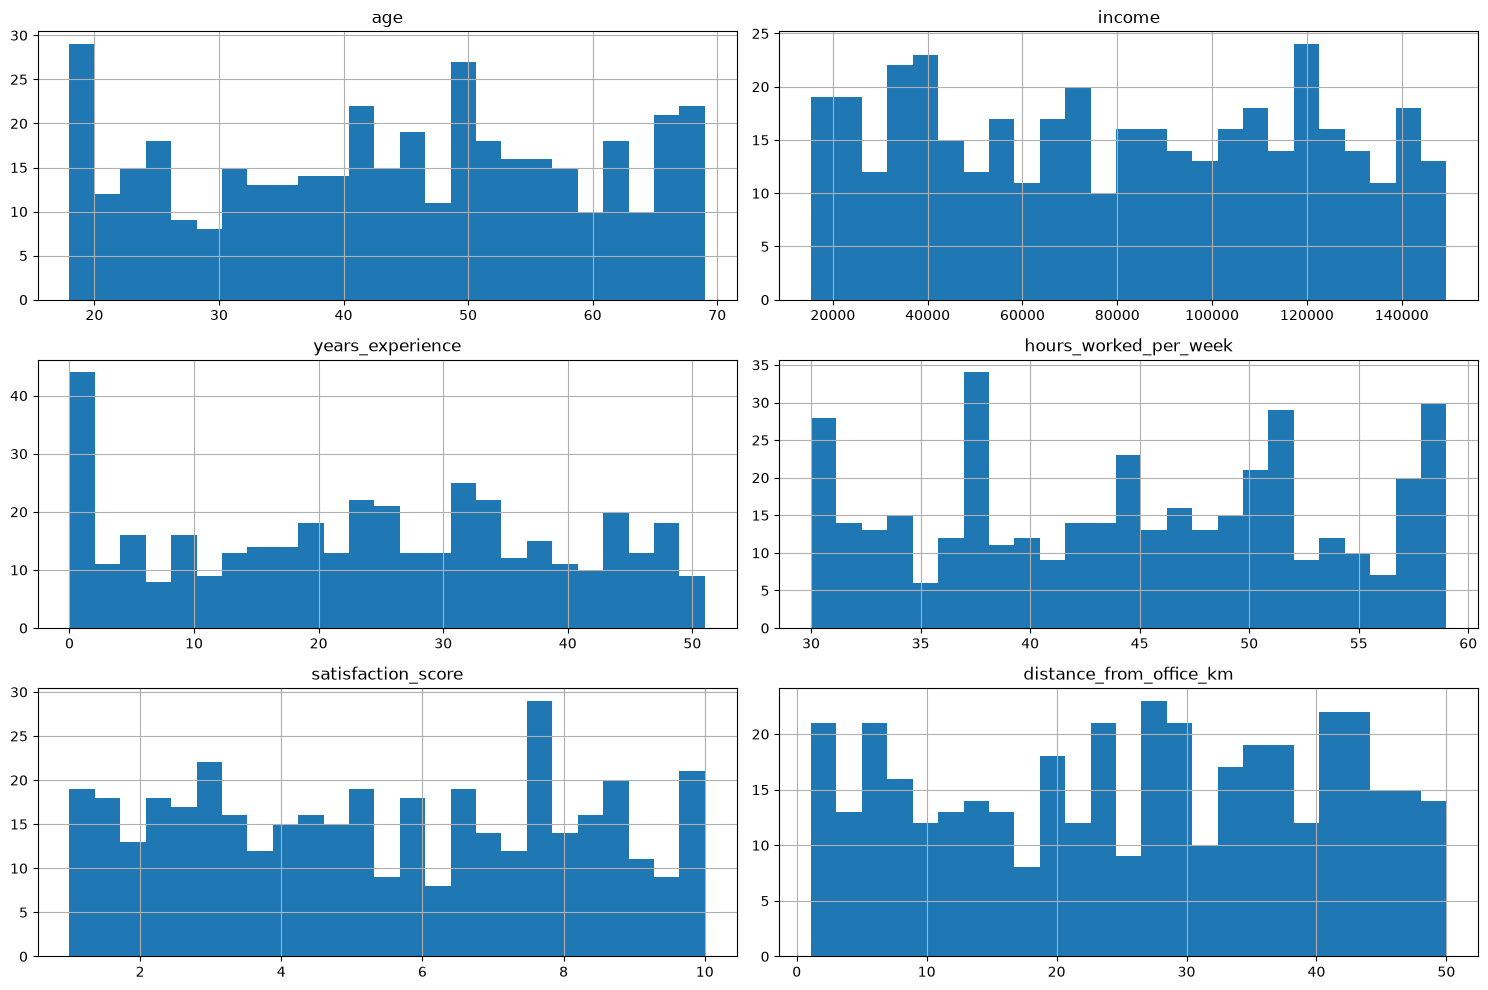

In [31]:
numeric_col=["age","income","years_experience","hours_worked_per_week","satisfaction_score","distance_from_office_km"]
dp[numeric_col].hist(bins=25,figsize=(15,10))
plt.tight_layout()
plt.show()

## Step 5: Categorical Column Breakdown

Looking at how records are distributed across categories like 
department and education — useful for spotting imbalances.

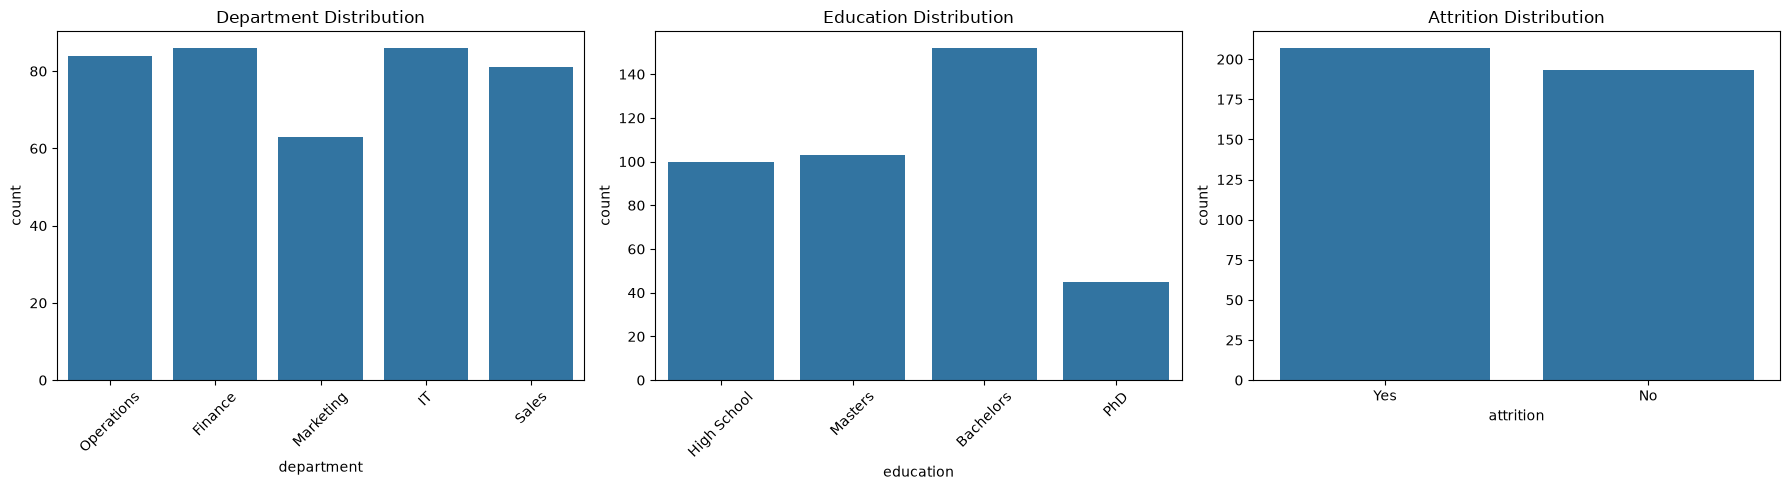

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=dp, x="department", ax=axes[0])
axes[0].set_title("Department Distribution")
axes[0].tick_params(axis='x', rotation=45)

sns.countplot(data=dp, x="education", ax=axes[1])
axes[1].set_title("Education Distribution")
axes[1].tick_params(axis='x', rotation=45)

sns.countplot(data=dp, x="attrition", ax=axes[2])
axes[2].set_title("Attrition Distribution")

plt.tight_layout()
plt.show()

## Step 6: Correlation Analysis

Checking how numeric variables relate to each other. Values close to 
+1 mean strong positive relationship, close to -1 mean strong negative 
relationship, close to 0 means little to no relationship.

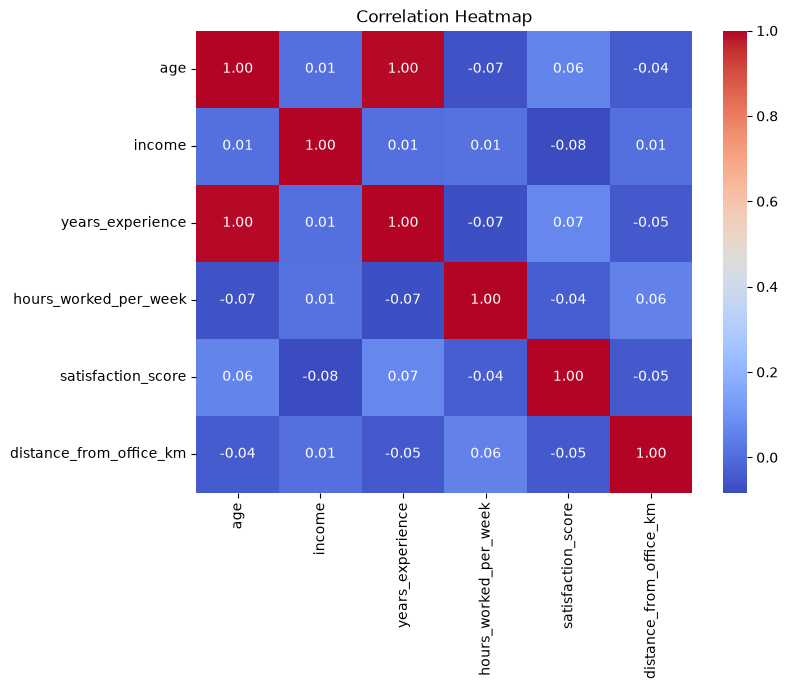

In [33]:
corr = dp[numeric_col].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## Step 7: Relationship Between Key Variables and Attrition

Exploring how attrition relates to satisfaction score and hours 
worked — two variables likely to influence whether an employee leaves.

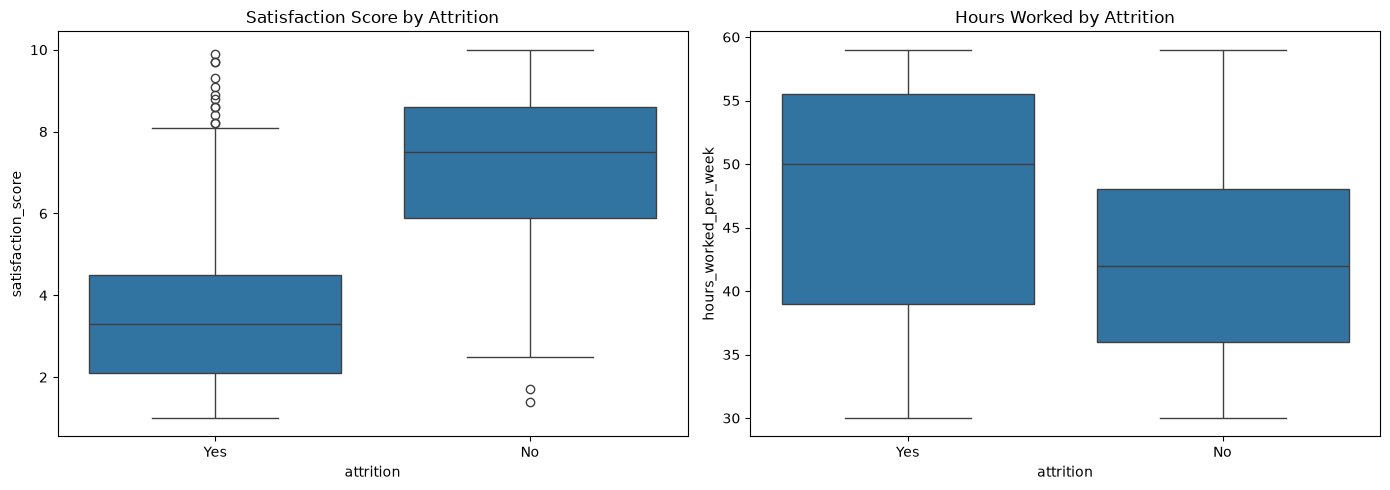

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=dp, x="attrition", y="satisfaction_score", ax=axes[0])
axes[0].set_title("Satisfaction Score by Attrition")

sns.boxplot(data=dp, x="attrition", y="hours_worked_per_week", ax=axes[1])
axes[1].set_title("Hours Worked by Attrition")

plt.tight_layout()
plt.show()

## Step 8: Department-wise Attrition Rate

Checking whether certain departments have higher attrition than others.

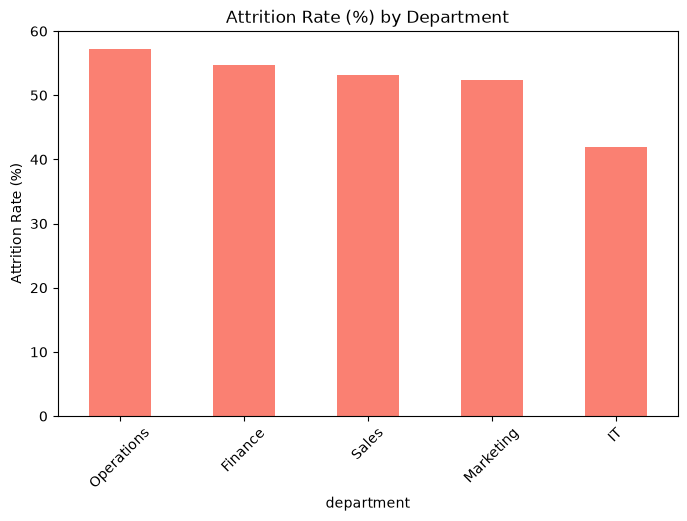

department
Operations    57.142857
Finance       54.651163
Sales         53.086420
Marketing     52.380952
IT            41.860465
Name: attrition, dtype: float64


In [35]:
attrition_by_dept = dp.groupby("department")["attrition"].apply(
    lambda x: (x == "Yes").mean() * 100
).sort_values(ascending=False)

attrition_by_dept.plot(kind="bar", figsize=(8, 5), color="salmon")
plt.title("Attrition Rate (%) by Department")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=45)
plt.show()

print(attrition_by_dept)

## Step 9: Key Findings & Insights

**1. Data Overview**
- Dataset contains 400 employee records with 10 features
- [Fill in: X missing values found / no missing values, X duplicate rows]

**2. Distribution Insights**
- [Fill in from Step 4 histograms, e.g. "income is roughly uniformly 
  distributed between ₹15,000–₹150,000"]

**3. Category Insights**
- [Fill in from Step 5, e.g. "Sales department has the most employees; 
  attrition is roughly balanced between Yes/No overall"]

**4. Correlation Insights**
- [Fill in from Step 6 heatmap, e.g. "satisfaction_score shows a 
  negative correlation with attrition-related patterns; age and 
  years_experience are strongly correlated as expected"]

**5. Attrition Patterns**
- [Fill in from Step 7-8, e.g. "employees who left had noticeably 
  lower satisfaction scores and higher weekly hours worked" / 
  "[Department name] has the highest attrition rate at X%"]

**Conclusion:**
This EDA revealed that satisfaction score and hours worked appear to 
be the strongest indicators of employee attrition, while department 
and education show more balanced distributions. These insights align 
with the feature importance findings from the earlier predictive 
modeling task, reinforcing satisfaction and workload as key drivers 
of attrition.